✅ Loaded 21613 records.


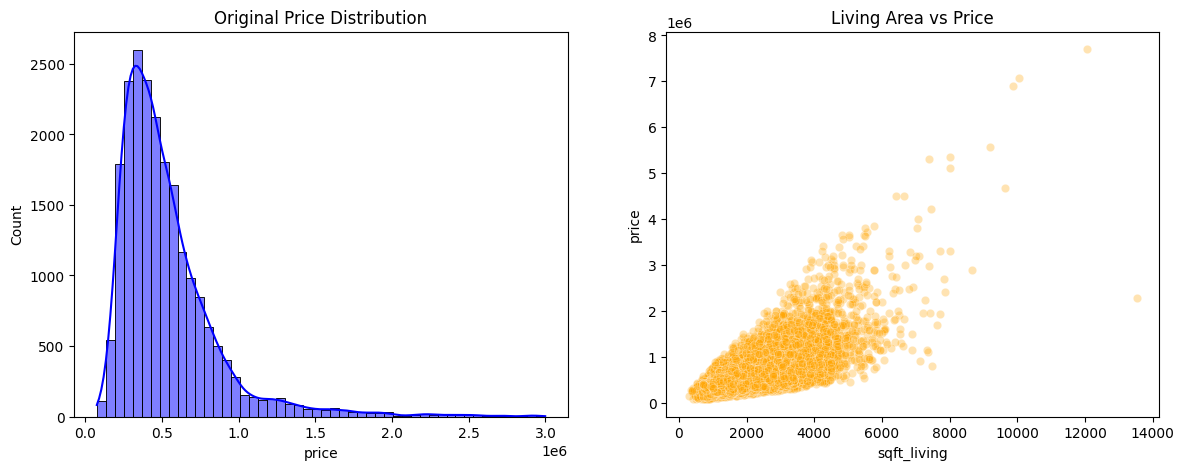

In [15]:
# Load dataset and initial trend analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("kc_house_data.csv")
print(f"✅ Loaded {len(df)} records.")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[df['price'] < 3000000]['price'], bins=50, kde=True, color='blue')
plt.title('Original Price Distribution')

plt.subplot(1, 2, 2)
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.3, color='orange')
plt.title('Living Area vs Price')
plt.show()

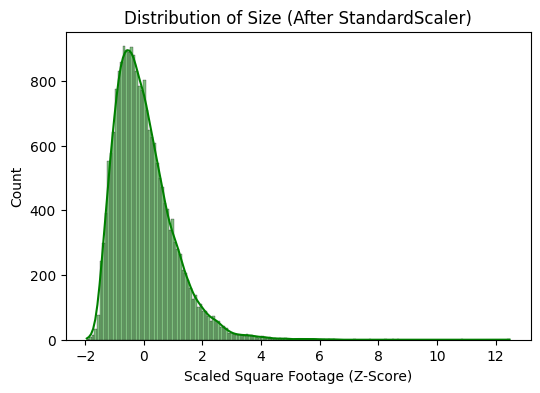

✅ Preprocessing and Scaling complete.


In [16]:
# Feature selection, scaling, and post-processing visualization
from sklearn.preprocessing import StandardScaler

features = ['bedrooms', 'bathrooms', 'sqft_living', 'lat', 'long']
X = df[features].copy()
y = df['price'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Visualization after preprocessing (Scaled Distribution)
plt.figure(figsize=(6, 4))
sns.histplot(X_scaled['sqft_living'], kde=True, color='green')
plt.title('Distribution of Size (After StandardScaler)')
plt.xlabel('Scaled Square Footage (Z-Score)')
plt.show()

print("✅ Preprocessing and Scaling complete.")

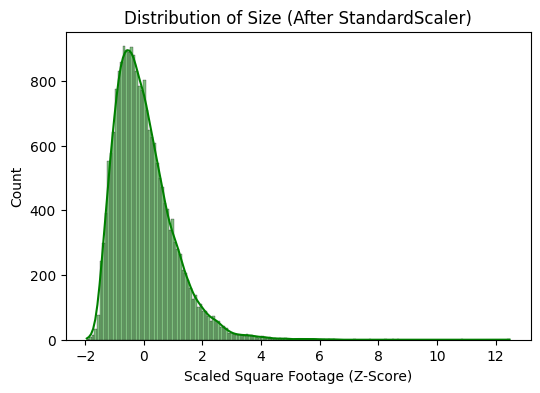

✅ Preprocessing and Scaling complete.


In [17]:
# Feature selection, scaling, and post-processing visualization
from sklearn.preprocessing import StandardScaler

features = ['bedrooms', 'bathrooms', 'sqft_living', 'lat', 'long']
X = df[features].copy()
y = df['price'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Visualization after preprocessing (Scaled Distribution)
plt.figure(figsize=(6, 4))
sns.histplot(X_scaled['sqft_living'], kde=True, color='green')
plt.title('Distribution of Size (After StandardScaler)')
plt.xlabel('Scaled Square Footage (Z-Score)')
plt.show()

print("✅ Preprocessing and Scaling complete.")

In [18]:
# Train Gradient Boosting Regressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("✅ Model training finished.")

✅ Model training finished.


MAE: $89,060.10
RMSE: $174,114.89


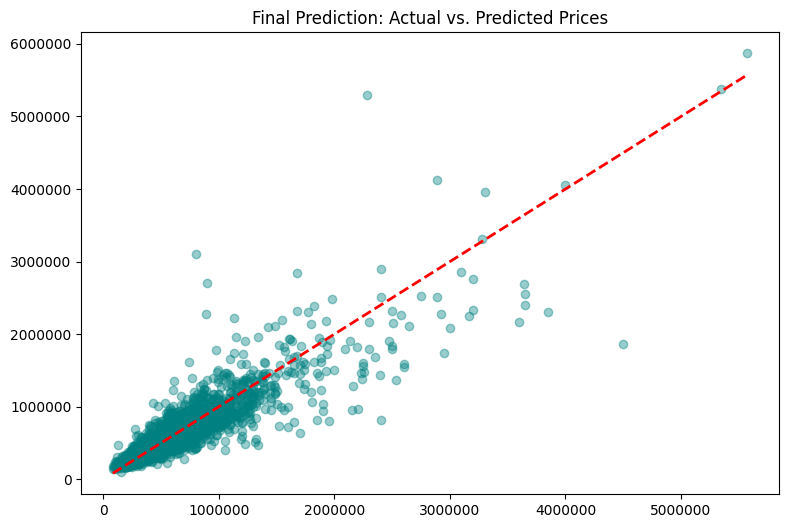

In [19]:
# Final performance metrics and prediction graph
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Final Prediction: Actual vs. Predicted Prices')
plt.ticklabel_format(style='plain', axis='both')
plt.show()